<a href="https://colab.research.google.com/github/Tanbir-Hasan-247/Colab-file/blob/main/Class_3_Spring_2026_(AI_LAB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Learning Objectives
By the end of this lab, students should be able to:

✅ Understand Classification vs. Regression problems.

✅ Implement various classification models:

* Logistic Regression
* K-Nearest Neighbors (KNN)
* Decision Tree Classifier
* Random Forest Classifier
* Support Vector Machine (SVM)

✅ Perform feature preprocessing (handling missing values, encoding categorical features).

✅ Train models and evaluate using accuracy, precision, recall, and F1-score.

✅ Use confusion matrices and ROC curves to analyze classification performance.


### 2. Introduction to Classification

####Q1: What is Classification?


* Classification is a Supervised Machine Learning task where the goal is to predict categorical labels (e.g., spam detection, medical diagnosis, sentiment analysis).
* The model learns a decision boundary to classify new data points into predefined categories.

<img src="https://miro.medium.com/v2/resize:fit:1342/format:webp/1*IYBep-wv-aHk11Q3ph1UkQ.png">

####Examples of Classification Problems
<table>
  <tr>
    <th>Application</th>
    <th>Classification Type</th>
    <th>Example Classes</th>
  </tr>
  <tr>
    <td>Spam Detection</td>
    <td>Binary Classification</td>
    <td>Spam (1), Not Spam (0)</td>
  </tr>
  <tr>
    <td>Medical Diagnosis</td>
    <td>Multi-Class Classification</td>
    <td>Healthy, Diabetes, Heart Disease</td>
  </tr>
  <tr>
    <td>Sentiment Analysis</td>
    <td>Multi-Class Classification</td>
    <td>Positive, Neutral, Negative</td>
  </tr>
  <tr>
    <td>Credit Card Fraud Detection</td>
    <td>Binary Classification</td>
    <td>Fraud (1), No Fraud (0)</td>
  </tr>
  <tr>
    <td>Handwritten Digit Recognition</td>
    <td>Multi-Class Classification</td>
    <td>Digits 0 to 9</td>
  </tr>
  <tr>
    <td>Customer Churn Prediction</td>
    <td>Binary Classification</td>
    <td>Churn (1), No Churn (0)</td>
  </tr>
  <tr>
    <td>Object Recognition in Images</td>
    <td>Multi-Class Classification</td>
    <td>Car, Bike, Person, Animal, etc.</td>
  </tr>
  <tr>
    <td>Email Categorization</td>
    <td>Multi-Class Classification</td>
    <td>Personal, Work, Promotions, Social</td>
  </tr>
  <tr>
    <td>Fake News Detection</td>
    <td>Binary Classification</td>
    <td>Fake (1), Real (0)</td>
  </tr>
  <tr>
    <td>Speech Emotion Recognition</td>
    <td>Multi-Class Classification</td>
    <td>Happy, Sad, Angry, Neutral</td>
  </tr>
</table>


#=====================================================================================================

###3. Importing Libraries and Dataset
📌 Load and explore the dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target  # Target variable (0 = Benign, 1 = Malignant)

# Display first 5 rows
print("First 5 Rows of Dataset:\n", df.head())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Display class distribution
print("\nClass Distribution:\n", df["target"].value_counts())

First 5 Rows of Dataset:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wo

In [ ]:
print(df)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [ ]:
# Display all rows
pd.set_option('display.max_rows', None)

# Display all columns
pd.set_option('display.max_columns', None)

# Print the entire dataset
print(df)

# Reset settings after viewing (optional)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0         17.990         10.38          122.80     1001.0          0.11840   
1         20.570         17.77          132.90     1326.0          0.08474   
2         19.690         21.25          130.00     1203.0          0.10960   
3         11.420         20.38           77.58      386.1          0.14250   
4         20.290         14.34          135.10     1297.0          0.10030   
5         12.450         15.70           82.57      477.1          0.12780   
6         18.250         19.98          119.60     1040.0          0.09463   
7         13.710         20.83           90.20      577.9          0.11890   
8         13.000         21.82           87.50      519.8          0.12730   
9         12.460         24.04           83.97      475.9          0.11860   
10        16.020         23.24          102.70      797.8          0.08206   
11        15.780         17.89          103.60      781.0       

###4. Exploratory Data Analysis (EDA)

📌 Understanding Data Distribution

In [ ]:
# Display summary statistics
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [ ]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


target
1    357
0    212
Name: count, dtype: int64


<ipython-input-6-5c2d1afda590>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["target"], palette=["blue", "red"])


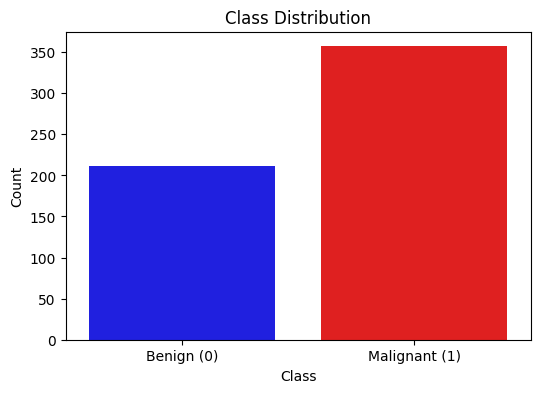

In [ ]:
# Check class distribution
print(df["target"].value_counts())

# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["target"], palette=["blue", "red"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Benign (0)", "Malignant (1)"])
plt.show()

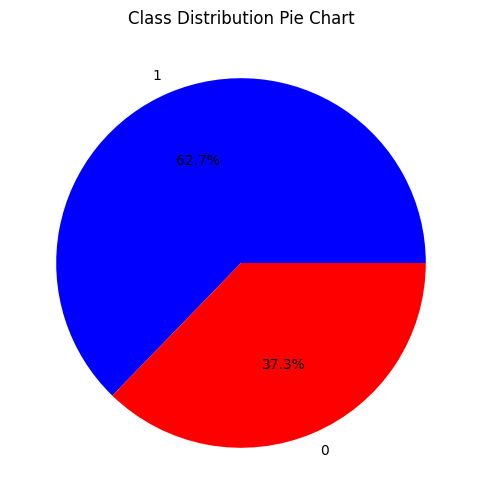

In [ ]:
plt.figure(figsize=(6, 6))
df["target"].value_counts().plot.pie(autopct='%1.1f%%', colors=["blue", "red"])
plt.title("Class Distribution Pie Chart")
plt.ylabel("")
plt.show()

In [ ]:
minority_class = df["target"].value_counts().min()
majority_class = df["target"].value_counts().max()

imbalance_ratio = majority_class / minority_class
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Imbalance Ratio: 1.68


✔ If IR > 2, the dataset is imbalanced. If IR > 10, it's highly imbalanced.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(df["target"]), y=df["target"])
print("Class Weights:", class_weights)

Class Weights: [1.34198113 0.79691877]


✔ Higher weight values indicate a class is underrepresented.

##### **TO DO** : Learn how to balance dataset if it is imbalanced

###5. Splitting Data into Training and Testing Sets

📌 80% Training – 20% Testing

In [ ]:
# Define features (X) and target variable (Y)
X = df.drop(columns=["target"])
Y = df["target"]

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Standardize the data (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


✔ Feature scaling is necessary for algorithms like Logistic Regression, KNN, and SVM.

###6. Implementing Classification Models

(A) Logistic Regression

📌 Train and evaluate Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression Model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, Y_train)

# Predict
Y_pred_logistic = logistic_model.predict(X_test_scaled)

# Evaluate Model
print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(Y_test, Y_pred_logistic))
print("Classification Report:\n", classification_report(Y_test, Y_pred_logistic))

Logistic Regression Performance:
Accuracy: 0.9736842105263158
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



✔ A simple and interpretable model for classification problems.

(B) K-Nearest Neighbors (KNN)

📌 Train and evaluate KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, Y_train)

# Predict
Y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate Model
print("KNN Performance:")
print("Accuracy:", accuracy_score(Y_test, Y_pred_knn))
print("Classification Report:\n", classification_report(Y_test, Y_pred_knn))

KNN Performance:
Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



✔ KNN considers nearest neighbors for classification.

(C) Decision Tree Classifier

📌 Train and evaluate Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Model
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, Y_train)

# Predict
Y_pred_tree = tree_model.predict(X_test)

# Evaluate Model
print("Decision Tree Performance:")
print("Accuracy:", accuracy_score(Y_test, Y_pred_tree))
print("Classification Report:\n", classification_report(Y_test, Y_pred_tree))


Decision Tree Performance:
Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



✔ Works well with unscaled data and handles non-linear relationships.

(D) Random Forest Classifier

📌 Train and evaluate Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=101,   # number of trees
    max_depth=5,        # limit tree depth (optional)
    random_state=42
)
rf_model.fit(X_train, Y_train)

# Predict
Y_pred_rf = rf_model.predict(X_test)

# Evaluate Model
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print("Classification Report:\n", classification_report(Y_test, Y_pred_rf))

Decision Tree Performance:
Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



✔ Handles overfitting better than Decision Trees.

##### **TO DO** : Learn About Overfitting and Underfitting

(E) Support Vector Machine (SVM)

📌 Train and evaluate SVM

In [ ]:
from sklearn.svm import SVC

# Train SVM Model
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_scaled, Y_train)

# Predict
Y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate Model
print("SVM Performance:")
print("Accuracy:", accuracy_score(Y_test, Y_pred_svm))
print("Classification Report:\n", classification_report(Y_test, Y_pred_svm))

SVM Performance:
Accuracy: 0.956140350877193
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



✔ SVM is effective for high-dimensional data.

###7. Model Evaluation
Confusion Matrix

📌 Plot confusion matrix for all models

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


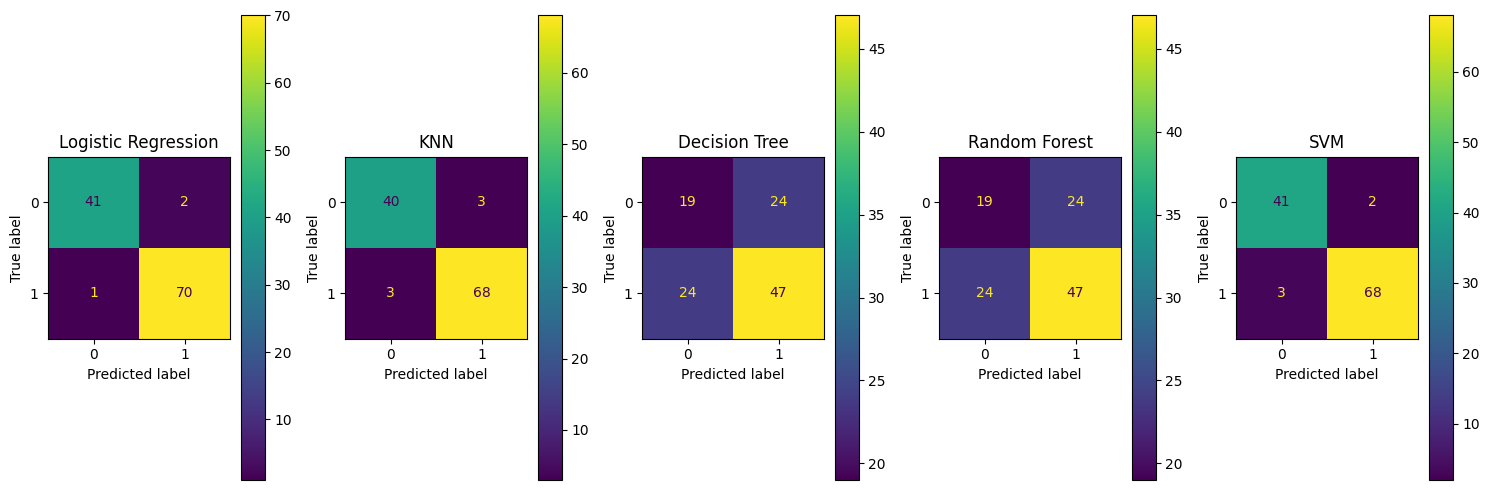

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {"Logistic Regression": logistic_model, "KNN": knn_model, "Decision Tree": tree_model, "Random Forest": rf_model, "SVM": svm_model}
plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items()):
    plt.subplot(1, 5, i+1)
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, Y_test, ax=plt.gca())
    plt.title(name)

plt.tight_layout()
plt.show()

✔ Visualizes how well each model classifies the data.